In [ ]:
#@title Tracker, Contradiction Handling, Qwen Agent (Single Dialogue JSON)

import json
from typing import Dict
from google.colab import files

# ----------------------------
# Preference Tracker
# ----------------------------
class PreferenceTracker:
    def __init__(self):
        self.preferences: Dict[str, Dict[str, float]] = {}

    def update_explicit(self, key: str, value: str):
        self.preferences[key] = {"value": value, "weight": 1.0}
        print(f"[Tracker] Explicitly set {key} = {value} (weight = 1.0)")

    def update_contradiction(self, key: str, opposing_value: str, threshold: float = 0.3):
        if key in self.preferences:
            self.preferences[key]['weight'] -= 0.1
            print(f"[Tracker] Decreased weight for {key} to {self.preferences[key]['weight']:.2f}")
            if self.preferences[key]['weight'] < threshold:
                print(f"[Tracker] Discarding {key} due to low weight.")
                del self.preferences[key]
                self.preferences[key] = {"value": opposing_value, "weight": 0.5}
                print(f"[Tracker] Adopted new {key} = {opposing_value} (weight = 0.5)")
        else:
            self.preferences[key] = {"value": opposing_value, "weight": 0.5}
            print(f"[Tracker] New inferred {key} = {opposing_value} (weight = 0.5)")

    def get_state(self) -> Dict:
        return self.preferences


# ----------------------------
# Qwen Agent
# ----------------------------
class QwenAgent:
    def generate_response(self, user_input: str, preferences: Dict) -> str:
        pref_string = ", ".join(f"{k}={v['value']}" for k, v in preferences.items())
        return f"(QwenStub) Responding to: '{user_input}' with preferences [{pref_string}]"


# ----------------------------
# Upload and Parse Single JSON Object File
# ----------------------------
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

with open(file_name, 'r') as f:
    entry = json.load(f)  # Single dict, not a list

print("\n" + "="*80)
print("👤 Persona:", entry.get("Original Persona"))
print("📚 Topic:", entry.get("Topic"))

tracker = PreferenceTracker()
agent = QwenAgent()

# Build a map of contradictions keyed by current turn_id
contradiction_map = {c["curr_turn_id"]: c for c in entry.get("Contradiction", [])}

# Run through conversation
for turn in entry["Conversation"]:
    speaker = turn["speaker"]
    text = turn["text"]
    turn_id = turn["turn_id"]

    print(f"\n{'🧑' if speaker == 'user' else '🤖'} {speaker.title()} [{turn_id}]: {text}")

    if speaker == "user":
        if turn_id in contradiction_map:
            c = contradiction_map[turn_id]
            curr_pref = c["curr_pref"]
            prev_pref = c["prev_pref"]
            certainty = c.get("certainty", "low")
            key = f"pref_{turn_id}"  # Using turn_id as key for preference tracking

            print(f"⚠️ Detected contradiction: \"{prev_pref}\" → \"{curr_pref}\" (certainty: {certainty})")

            if certainty in ("high", "medium"):
                tracker.update_explicit(key, curr_pref)
            else:
                tracker.update_contradiction(key, curr_pref)

        # Simulate agent response to user input
        response = agent.generate_response(text, tracker.get_state())
        print("🤖 Agent:", response)

print("\n✅ Finished processing the dialogue.")

Saving conversation_studyConsultation_persona0_sample0.json to conversation_studyConsultation_persona0_sample0 (2).json

👤 Persona: A fellow Sac State alum who specializes in marketing and branding
📚 Topic: studyConsultation

🧑 User [0]: Hi there! I'm looking for some guidance on improving my study techniques. Being a marketing professional, I want to ensure I stay sharp with the latest trends.
🤖 Agent: (QwenStub) Responding to: 'Hi there! I'm looking for some guidance on improving my study techniques. Being a marketing professional, I want to ensure I stay sharp with the latest trends.' with preferences []

🤖 Agent [1]: Hello, Javier! It’s great to hear that you’re committed to lifelong learning. What specific areas are you interested in improving? Do you have any particular techniques you’ve tried before?

🧑 User [2]: I’ve tried various techniques like active reading and summarization, but I feel like I’m not retaining information as well as I could. I want to focus on integrating st

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Upload your ZIP file containing JSON dialogues:


Saving cs224r demo data2.zip to cs224r demo data2 (5).zip
Extracted all files to /content/extracted_jsons
Found 9 JSON files to process.
Processing JSON file: /content/extracted_jsons/output/healthConsultation/conversation_healthConsultation_persona0_sample0.json

Processing file: conversation_healthConsultation_persona0_sample0.json
👤 Persona: A fellow Sac State alum who specializes in marketing and branding
📚 Topic: healthConsultation
⚠️ Detected contradiction (turn 8): "love cooking with traditional ingredients" → "interested in veganism" (certainty: medium)
⚠️ Detected contradiction (turn 12): "considering going vegan" → "want to take baby steps in diet" (certainty: medium)
⚠️ Detected contradiction (turn 16): "tend to skip them" → "need to look into regular health checkups" (certainty: high)
⚠️ Detected contradiction (turn 20): "only walking is enough" → "want to get back into regular workouts" (certainty: high)
⚠️ Detected contradiction (turn 22): "thought it might be too hard on

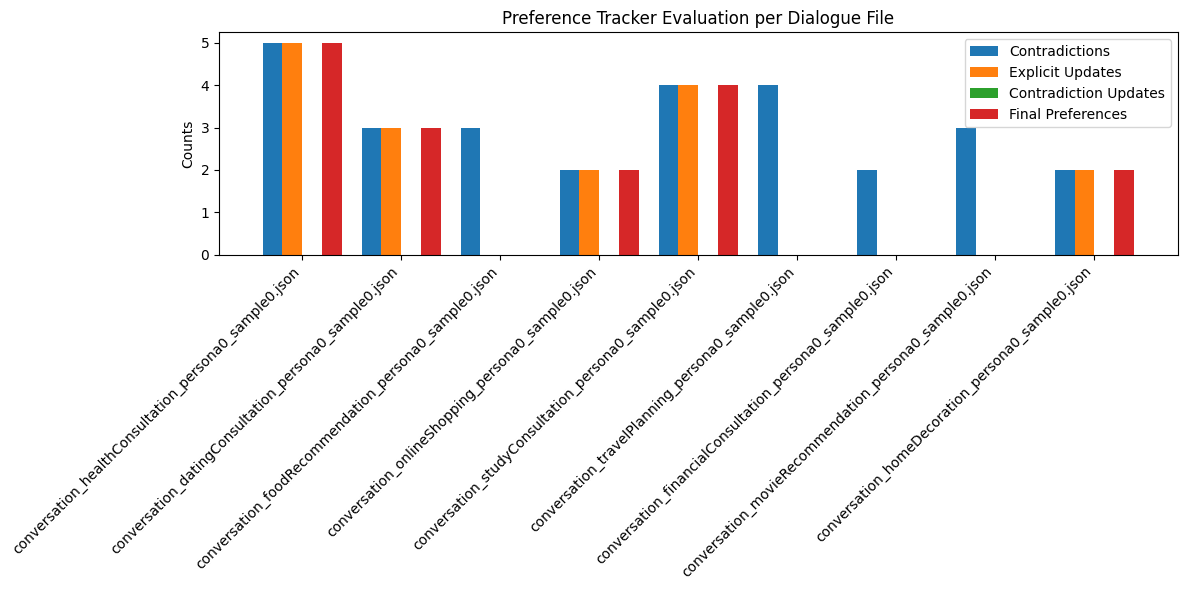

Saved evaluation summary to /content/drive/My Drive/PreferenceTrackerResults/eval_summary.json


In [ ]:
# Step 0: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
import zipfile
import glob
import json
from typing import Dict
import matplotlib.pyplot as plt
from google.colab import files

# Define where to save results in your Drive
save_dir = '/content/drive/My Drive/PreferenceTrackerResults'
os.makedirs(save_dir, exist_ok=True)

# Step 1: Upload ZIP file
print("Upload your ZIP file containing JSON dialogues:")
uploaded = files.upload()

# Get uploaded zip filename (expect only one)
zip_filename = list(uploaded.keys())[0]

# Step 2: Extract ZIP
extract_folder = '/content/extracted_jsons'
os.makedirs(extract_folder, exist_ok=True)

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print(f"Extracted all files to {extract_folder}")

# ----------------------------
# Preference Tracker and QwenAgent classes
# ----------------------------

class PreferenceTracker:
    def __init__(self):
        self.preferences: Dict[str, Dict[str, float]] = {}
        self.explicit_updates = 0
        self.contradiction_updates = 0

    def update_explicit(self, key: str, value: str):
        self.preferences[key] = {"value": value, "weight": 1.0}
        self.explicit_updates += 1

    def update_contradiction(self, key: str, opposing_value: str, threshold: float = 0.3):
        if key in self.preferences:
            self.preferences[key]['weight'] -= 0.1
            if self.preferences[key]['weight'] < threshold:
                del self.preferences[key]
                self.preferences[key] = {"value": opposing_value, "weight": 0.5}
        else:
            self.preferences[key] = {"value": opposing_value, "weight": 0.5}
        self.contradiction_updates += 1

    def get_state(self) -> Dict:
        return self.preferences

class QwenAgent:
    def generate_response(self, user_input: str, preferences: Dict) -> str:
        pref_string = ", ".join(f"{k}={v['value']}" for k, v in preferences.items())
        return f"(QwenStub) Responding to: '{user_input}' with preferences [{pref_string}]"


# Step 3: Process all JSON files in extracted folder recursively

json_files = glob.glob(os.path.join(extract_folder, '**', '*.json'), recursive=True)
print(f"Found {len(json_files)} JSON files to process.")

eval_results = []

for json_file in json_files:
    print(f"Processing JSON file: {json_file}")
    with open(json_file, 'r', encoding='utf-8') as f:
        entry = json.load(f)

    print("\n" + "="*80)
    print(f"Processing file: {os.path.basename(json_file)}")
    print("👤 Persona:", entry.get("Original Persona"))
    print("📚 Topic:", entry.get("Topic"))

    tracker = PreferenceTracker()
    agent = QwenAgent()

    contradiction_map = {c["curr_turn_id"]: c for c in entry.get("Contradiction", [])}

    contradiction_detected_count = len(contradiction_map)
    user_turn_count = 0

    for turn in entry["Conversation"]:
        speaker = turn["speaker"]
        text = turn["text"]
        turn_id = turn["turn_id"]

        if speaker == "user":
            user_turn_count += 1

            if turn_id in contradiction_map:
                c = contradiction_map[turn_id]
                curr_pref = c["curr_pref"]
                prev_pref = c["prev_pref"]
                certainty = c.get("certainty", "low")
                key = f"pref_{turn_id}"

                print(f"⚠️ Detected contradiction (turn {turn_id}): \"{prev_pref}\" → \"{curr_pref}\" (certainty: {certainty})")

                if certainty in ("high", "medium"):
                    tracker.update_explicit(key, curr_pref)
                else:
                    tracker.update_contradiction(key, curr_pref)

    eval_results.append({
        "file": os.path.basename(json_file),
        "user_turns": user_turn_count,
        "contradictions": contradiction_detected_count,
        "explicit_updates": tracker.explicit_updates,
        "contradiction_updates": tracker.contradiction_updates,
        "final_preferences": len(tracker.get_state())
    })

print("\n✅ Finished processing all dialogues.")

# Step 4: Debug print evaluation summary before plotting

print("\nEvaluation results summary:")
for r in eval_results:
    print(r)

# Step 5: Plot and save results

files_ = [r["file"] for r in eval_results]
contradictions = [r["contradictions"] for r in eval_results]
explicit_updates = [r["explicit_updates"] for r in eval_results]
contradiction_updates = [r["contradiction_updates"] for r in eval_results]
final_prefs = [r["final_preferences"] for r in eval_results]

import numpy as np

fig, ax = plt.subplots(figsize=(12, 6))
width = 0.2
x = np.arange(len(files_))

ax.bar(x, contradictions, width=width, label="Contradictions")
ax.bar(x + width, explicit_updates, width=width, label="Explicit Updates")
ax.bar(x + 2*width, contradiction_updates, width=width, label="Contradiction Updates")
ax.bar(x + 3*width, final_prefs, width=width, label="Final Preferences")

ax.set_xticks(x + 1.5*width)
ax.set_xticklabels(files_, rotation=45, ha='right')
ax.set_ylabel("Counts")
ax.set_title("Preference Tracker Evaluation per Dialogue File")
ax.legend()
plt.tight_layout()

plot_path = os.path.join(save_dir, 'evaluation_plot.png')
plt.savefig(plot_path)
print(f"Saved plot to {plot_path}")
plt.show()

# Save evaluation summary JSON
summary_path = os.path.join(save_dir, 'eval_summary.json')
with open(summary_path, 'w') as f:
    json.dump(eval_results, f, indent=2)
print(f"Saved evaluation summary to {summary_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Upload the zipped JSON file:


Saving cs224r demo data2.zip to cs224r demo data2 (8).zip
Unzipped files to /content/json_dialogues
Found 9 JSON files to process.

=== Processing file: conversation_healthConsultation_persona0_sample0.json ===
Certainty values found in this file: {'medium', 'high'}
User turn 0 has no contradiction.
Similarity score added: 1.0000
User turn 2 has no contradiction.
Similarity score added: 1.0000
User turn 4 has no contradiction.
Similarity score added: 1.0000
User turn 6 has no contradiction.
Similarity score added: 1.0000
User turn 8 has contradiction: prev_pref=love cooking with traditional ingredients, curr_pref=interested in veganism, certainty=medium
[Tracker] Explicitly set pref_8 = interested in veganism (weight = 1.0)
[CountingTracker] Counted explicit update with certainty 'medium'
Similarity score added: 0.9223
User turn 10 has no contradiction.
Similarity score added: 0.9287
User turn 12 has contradiction: prev_pref=considering going vegan, curr_pref=want to take baby steps in

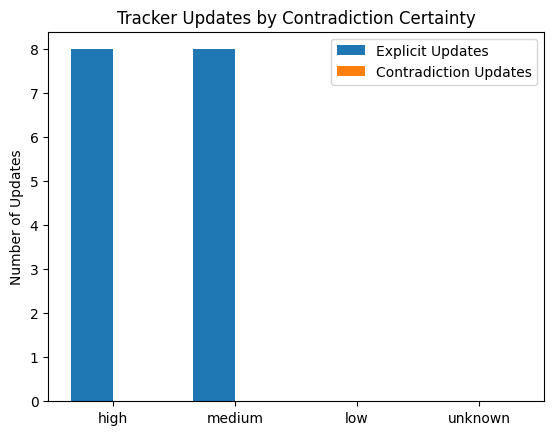

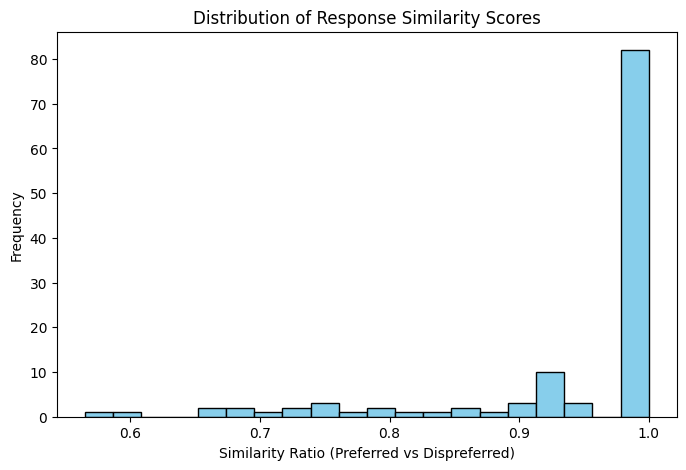

Plots saved to your Google Drive at MyDrive folder.


In [ ]:
from google.colab import drive, files
import zipfile
import os
import json
import matplotlib.pyplot as plt
from difflib import SequenceMatcher
from collections import defaultdict
import numpy as np

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Upload your zipped JSON archive
print("Upload the zipped JSON file:")
uploaded = files.upload()
zip_name = list(uploaded.keys())[0]

# 3. Unzip uploaded file to a folder
unzip_dir = "/content/json_dialogues"
os.makedirs(unzip_dir, exist_ok=True)

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall(unzip_dir)
print(f"Unzipped files to {unzip_dir}")

# 4. Define similarity helper
def similarity_ratio(a, b):
    return SequenceMatcher(None, a, b).ratio()

# 5. Define base PreferenceTracker class
class PreferenceTracker:
    def __init__(self):
        self.preferences = {}

    def update_explicit(self, key: str, value: str):
        self.preferences[key] = {"value": value, "weight": 1.0}
        print(f"[Tracker] Explicitly set {key} = {value} (weight = 1.0)")

    def update_contradiction(self, key: str, opposing_value: str, threshold: float = 0.3):
        if key in self.preferences:
            self.preferences[key]['weight'] -= 0.1
            print(f"[Tracker] Decreased weight for {key} to {self.preferences[key]['weight']:.2f}")
            if self.preferences[key]['weight'] < threshold:
                print(f"[Tracker] Discarding {key} due to low weight.")
                del self.preferences[key]
                self.preferences[key] = {"value": opposing_value, "weight": 0.5}
                print(f"[Tracker] Adopted new {key} = {opposing_value} (weight = 0.5)")
        else:
            self.preferences[key] = {"value": opposing_value, "weight": 0.5}
            print(f"[Tracker] New inferred {key} = {opposing_value} (weight = 0.5)")

    def get_state(self):
        return self.preferences

# 6. Setup global update counts for experiment 4
update_counts = {
    "high": {"explicit": 0, "contradiction": 0},
    "medium": {"explicit": 0, "contradiction": 0},
    "low": {"explicit": 0, "contradiction": 0},
    "unknown": {"explicit": 0, "contradiction": 0}
}

# 7. Counting tracker subclass with debug prints
class CountingPreferenceTracker(PreferenceTracker):
    def update_explicit(self, key: str, value: str, certainty="unknown"):
        super().update_explicit(key, value)
        c = certainty.lower() if isinstance(certainty, str) else "unknown"
        if c not in update_counts:
            c = "unknown"
        update_counts[c]["explicit"] += 1
        print(f"[CountingTracker] Counted explicit update with certainty '{c}'")

    def update_contradiction(self, key: str, opposing_value: str, certainty="unknown", threshold: float = 0.3):
        super().update_contradiction(key, opposing_value, threshold)
        c = certainty.lower() if isinstance(certainty, str) else "unknown"
        if c not in update_counts:
            c = "unknown"
        update_counts[c]["contradiction"] += 1
        print(f"[CountingTracker] Counted contradiction update with certainty '{c}'")

# 8. QwenAgent stub
class QwenAgent:
    def generate_response(self, user_input: str, preferences: dict) -> str:
        pref_string = ", ".join(f"{k}={v['value']}" for k, v in preferences.items())
        return f"(QwenStub) Responding to: '{user_input}' with preferences [{pref_string}]"

# 9. Prepare similarity scores accumulator
similarity_scores = []

# 10. Process all JSON files
json_files = glob.glob(os.path.join(unzip_dir, '**', '*.json'), recursive=True)
print(f"Found {len(json_files)} JSON files to process.")

for fpath in json_files:
    fname = os.path.basename(fpath)
    print(f"\n=== Processing file: {fname} ===")
    with open(fpath, 'r', encoding='utf-8') as f:
        entry = json.load(f)

    # Debug print certainties found in this file
    certainties_found = set()
    for c in entry.get("Contradiction", []):
        cert = c.get("certainty", "unknown")
        certainties_found.add(cert)
    print(f"Certainty values found in this file: {certainties_found}")

    tracker = CountingPreferenceTracker()
    agent = QwenAgent()

    contradiction_map = {c["curr_turn_id"]: c for c in entry.get("Contradiction", [])}

    for turn in entry["Conversation"]:
        speaker = turn["speaker"]
        text = turn["text"]
        turn_id = turn["turn_id"]

        if speaker == "user":
            if turn_id in contradiction_map:
                c = contradiction_map[turn_id]
                curr_pref = c["curr_pref"]
                certainty = c.get("certainty", "unknown")
                key = f"pref_{turn_id}"

                print(f"User turn {turn_id} has contradiction: prev_pref={c.get('prev_pref')}, curr_pref={curr_pref}, certainty={certainty}")

                if certainty.lower() in ("high", "medium"):
                    tracker.update_explicit(key, curr_pref, certainty=certainty)
                else:
                    tracker.update_contradiction(key, curr_pref, certainty=certainty)

            else:
                print(f"User turn {turn_id} has no contradiction.")

            # Generate preferred response using current tracker state
            preferred_response = agent.generate_response(text, tracker.get_state())
            # Generate dispreferred response (empty prefs)
            dispreferred_response = agent.generate_response(text, {})
            sim_score = similarity_ratio(preferred_response, dispreferred_response)
            similarity_scores.append(sim_score)
            print(f"Similarity score added: {sim_score:.4f}")

print("\n=== Processing complete ===")
print("Update counts by certainty:")
for cert in update_counts:
    print(f"  {cert}: Explicit={update_counts[cert]['explicit']}, Contradiction={update_counts[cert]['contradiction']}")

print(f"Total similarity scores collected: {len(similarity_scores)}")
print(f"Sample similarity scores: {similarity_scores[:5]}")

# 11. Plot experiment 4: Tracker updates by contradiction certainty
certainty_levels = ['high', 'medium', 'low', 'unknown']
explicit_vals = [update_counts[c]['explicit'] for c in certainty_levels]
contradiction_vals = [update_counts[c]['contradiction'] for c in certainty_levels]

x = np.arange(len(certainty_levels))
width = 0.35

fig, ax = plt.subplots()
ax.bar(x - width/2, explicit_vals, width, label='Explicit Updates')
ax.bar(x + width/2, contradiction_vals, width, label='Contradiction Updates')

ax.set_xticks(x)
ax.set_xticklabels(certainty_levels)
ax.set_ylabel('Number of Updates')
ax.set_title('Tracker Updates by Contradiction Certainty')
ax.legend()
plt.savefig('/content/drive/MyDrive/tracker_update_counts.png')
plt.show()

# 12. Plot experiment 5: Similarity scores histogram
plt.figure(figsize=(8,5))
plt.hist(similarity_scores, bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Similarity Ratio (Preferred vs Dispreferred)')
plt.ylabel('Frequency')
plt.title('Distribution of Response Similarity Scores')
plt.savefig('/content/drive/MyDrive/response_similarity_histogram.png')
plt.show()

print("Plots saved to your Google Drive at MyDrive folder.")
